In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
from sklearn.model_selection import train_test_split
import numpy as np

In [2]:
df= pd.read_csv("dataset/08-seismic_activity_svm.csv")

In [3]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


<Axes: xlabel='underground_wave_energy', ylabel='vibration_axis_variation'>

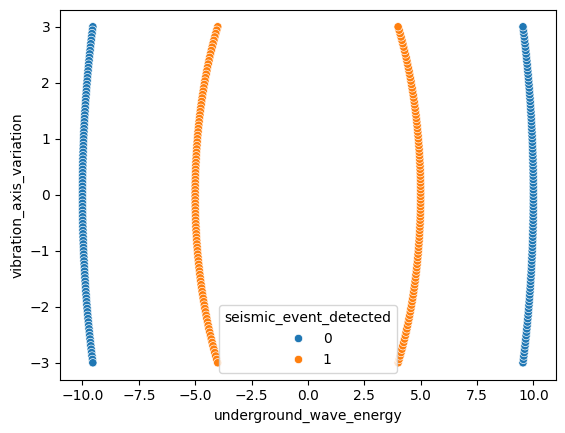

In [5]:
sns.scatterplot(x=df["underground_wave_energy"], y=df["vibration_axis_variation"], hue=df["seismic_event_detected"])

In [6]:
X= df[["vibration_axis_variation", "underground_wave_energy"]].values
y= df["seismic_event_detected"].values

In [7]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2, random_state=42)

In [8]:
print(len(X_train), len(X_test), len(y_train), len(y_test))
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

320 80 320 80
(320, 2) (80, 2) (320,) (80,)


In [9]:
X_train= torch.tensor(X_train, dtype= torch.float32)
X_test= torch.tensor(X_test, dtype= torch.float32)

y_train= torch.tensor(y_train, dtype= torch.float32).unsqueeze(1)
y_test= torch.tensor(y_test, dtype= torch.float32).unsqueeze(1)

In [10]:
class Classification(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1= nn.Linear(in_features=2, out_features=5)
        self.layer2= nn.Linear(in_features=5, out_features=1)
        self.relu= nn.ReLU()
        


    def forward(self, X:torch.tensor)->torch.tensor:
        return self.layer2(self.relu(self.layer1(X)))


In [11]:
model= Classification()
loss_fn= nn.BCEWithLogitsLoss()
optimizer= torch.optim.Adam(params=model.parameters(), lr=0.001)

In [12]:
def calculate_accuracy(y_test:torch.tensor, y_pred:torch.tensor)->float:
    correct= torch.eq(y_test,y_pred).sum().item()
    accuracy= (correct/len(y_test))*100
    return accuracy

In [17]:
torch.manual_seed(42)

epochs= 600

for epoch in range(epochs):
    model.train()
    y_logits= model(X_train)
    y_pred= torch.round(torch.sigmoid(y_logits))
    
    #train values
    loss= loss_fn(y_logits, y_train)
    acc= calculate_accuracy(y_train, y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    
    #test values
    model.eval()

    with torch.inference_mode():
        test_logits= model(X_test)
        test_pred= torch.round(torch.sigmoid(test_logits))
        
        test_loss= loss_fn(test_logits, y_test)
        test_accuracy= calculate_accuracy(y_test, test_pred)

        if epoch % 40==0:
            print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

Epoch: 0, Loss: 0.3572152554988861, Accuracy: 95.9375, Test Loss: 0.32369905710220337, Test Accuracy: 97.5
Epoch: 40, Loss: 0.33421891927719116, Accuracy: 100.0, Test Loss: 0.30453386902809143, Test Accuracy: 100.0
Epoch: 80, Loss: 0.30999431014060974, Accuracy: 100.0, Test Loss: 0.2837652564048767, Test Accuracy: 100.0
Epoch: 120, Loss: 0.282781183719635, Accuracy: 100.0, Test Loss: 0.2630508542060852, Test Accuracy: 100.0
Epoch: 160, Loss: 0.2557058334350586, Accuracy: 100.0, Test Loss: 0.24391253292560577, Test Accuracy: 100.0
Epoch: 200, Loss: 0.23249535262584686, Accuracy: 100.0, Test Loss: 0.22160062193870544, Test Accuracy: 100.0
Epoch: 240, Loss: 0.21187667548656464, Accuracy: 100.0, Test Loss: 0.20105919241905212, Test Accuracy: 100.0
Epoch: 280, Loss: 0.19361725449562073, Accuracy: 100.0, Test Loss: 0.18289172649383545, Test Accuracy: 100.0
Epoch: 320, Loss: 0.1773354709148407, Accuracy: 100.0, Test Loss: 0.16675697267055511, Test Accuracy: 100.0
Epoch: 360, Loss: 0.162752419

In [18]:
def plot_nonlinear_decision_boundary(model, X, y):

    # Grid alanını tanımla (tüm veri aralığını kapsasın)
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Grid'i modele sokmak için tensor'a çevir
    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    # Tahmin al
    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # probability map

    # Decision boundary çizimi (0.5 threshold)
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    
    # Gerçek noktalar
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

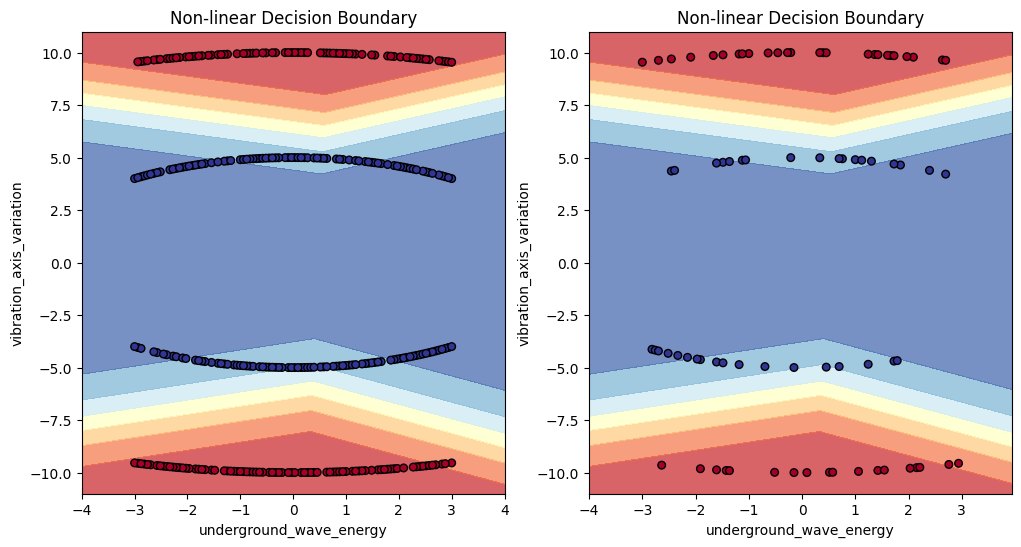

In [19]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model, X_test, y_test)

plt.show()